In [1]:
# License: BSD 3 clause

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

n_neighbors = 3
random_state = 0

# Load the data (replace with the actual path of your dataset)
data = pd.read_csv('data/domestic_violence_fake_data.csv')

# Split the data into features and target label 'Victim'
x = data[["Age", "Exchange_Sex", "Children", "Suicide_Attempt", "Jail", "Male", "LGBQ", "White", "Literal_Homeless", "Weapon", "Gang", "PTSD", "Depressed", "Community_Violence", "Sexual_Abuse", "Hard_Drug_Use", "Foster_Care", "Job"]]
y = data["Victim"]

# Split into train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.5, stratify=y, random_state=random_state
)


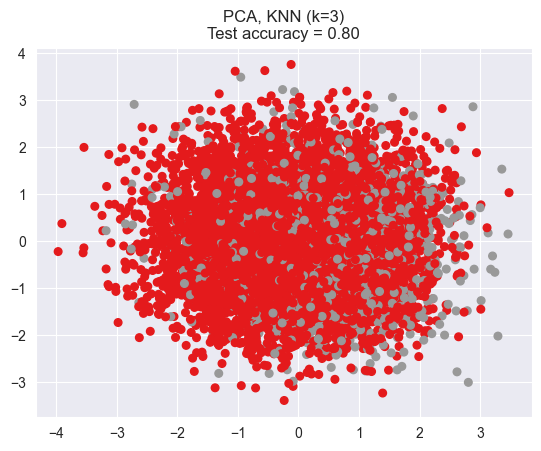

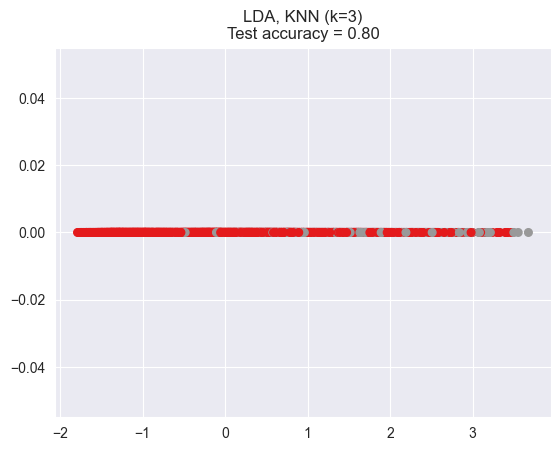

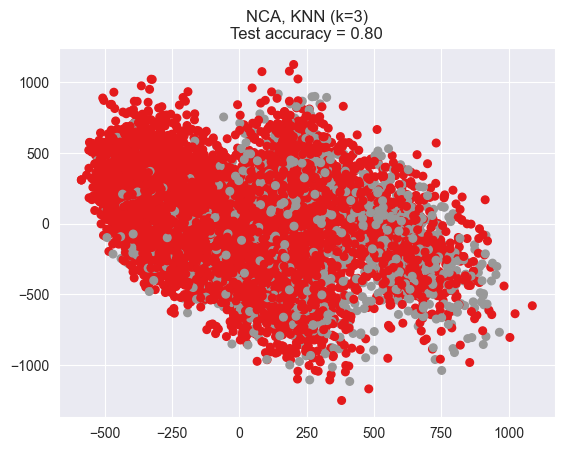

In [2]:

# Get the number of features (dimensions)
dim = x.shape[1]

# Get the number of unique classes in the target
n_classes = len(np.unique(y))

# Reduce dimension to 2 with PCA
pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=random_state))

# Dynamically determine the valid number of components for LDA
n_components_lda = min(x.shape[1], len(np.unique(y)) - 1)
lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=n_components_lda))

# Reduce dimension to 2 with NeighborhoodComponentAnalysis
nca = make_pipeline(
    StandardScaler(),
    NeighborhoodComponentsAnalysis(n_components=2, random_state=random_state),
)

# Use a nearest neighbor classifier to evaluate the methods
knn = KNeighborsClassifier(n_neighbors=n_neighbors)

# Make a list of the methods to be compared
dim_reduction_methods = [("PCA", pca), ("LDA", lda), ("NCA", nca)]

# Plot the results for each dimensionality reduction method
for i, (name, model) in enumerate(dim_reduction_methods):
    plt.figure()

    # Fit the method's model
    model.fit(x_train, y_train)

    # Fit a nearest neighbor classifier on the embedded training set
    knn.fit(model.transform(x_train), y_train)

    # Compute the nearest neighbor accuracy on the embedded test set
    acc_knn = knn.score(model.transform(x_test), y_test)

    # Embed the data set in 2 dimensions using the fitted model
    X_embedded = model.transform(x)

    # Check the number of dimensions in the transformed data
    if X_embedded.shape[1] == 1:
        # If 1D, plot the data along a single axis
        plt.scatter(X_embedded[:, 0], np.zeros_like(X_embedded[:, 0]), c=y, s=30, cmap="Set1")
        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )
    else:
        # If 2D, plot the data in 2D
        plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=y, s=30, cmap="Set1")
        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )

# Show all plots
plt.show()


Accuracy: 0.8158
F1 Score: 0.7806864786346325
Confusion Matrix:
[[4011  232]
 [ 689   68]]


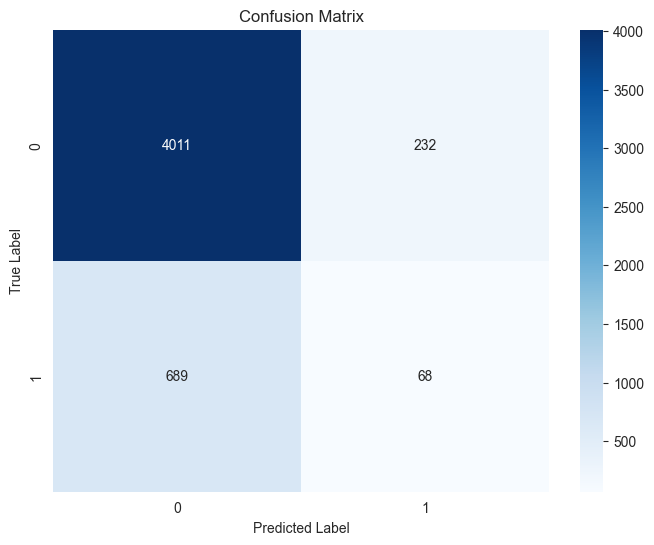

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix

# Initialize the KNeighborsClassifier
neigh = KNeighborsClassifier(n_neighbors=3)

# Scale the training and testing data
scaler = StandardScaler()
scaler.fit(x_train)
train_x = scaler.transform(x_train)
test_x = scaler.transform(x_test)

# Fit the model
neigh.fit(train_x, y_train)

# Make predictions on the test set
y_pred = neigh.predict(test_x)

# Calculate accuracy
accuracy = neigh.score(test_x, y_test)
print(f"Accuracy: {accuracy}")

# Calculate F1 score
f1 = f1_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1}")

# Print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


Accuracy: 0.5726666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.59      0.70      2546
           1       0.17      0.46      0.25       454

    accuracy                           0.57      3000
   macro avg       0.51      0.53      0.47      3000
weighted avg       0.76      0.57      0.63      3000



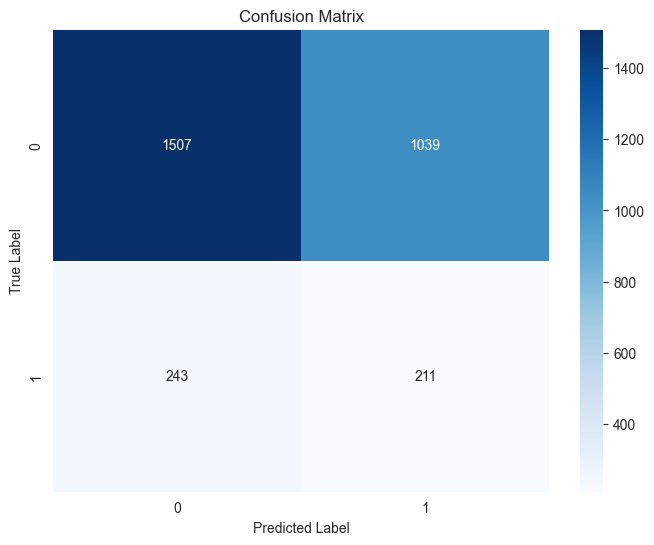

In [4]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE  # Import SMOTE

# Load your dataset (replace this with your actual data loading method)
data = pd.read_csv('data/domestic_violence_fake_data.csv')

# Features and target
x = data.drop("Victim", axis=1)  # Replace with the relevant features
y = data["Victim"]  # Target column (assuming this is the target in your dataset)

# Split the dataset into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, stratify=y)

# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Create the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = knn.predict(x_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()